In [1]:
!lscpu

Architecture:                x86_64
  CPU op-mode(s):            32-bit, 64-bit
  Address sizes:             52 bits physical, 57 bits virtual
  Byte Order:                Little Endian
CPU(s):                      192
  On-line CPU(s) list:       0-191
Vendor ID:                   AuthenticAMD
  Model name:                AMD EPYC 9684X 96-Core Processor
    CPU family:              25
    Model:                   17
    Thread(s) per core:      1
    Core(s) per socket:      96
    Socket(s):               2
    Stepping:                2
    Frequency boost:         enabled
    CPU(s) scaling MHz:      60%
    CPU max MHz:             3715.4290
    CPU min MHz:             1500.0000
    BogoMIPS:                5099.64
    Flags:                   fpu vme de pse tsc msr pae mce cx8 apic sep mtrr pg
                             e mca cmov pat pse36 clflush mmx fxsr sse sse2 ht s
                             yscall nx mmxext fxsr_opt pdpe1gb rdtscp lm constan
                         

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
import time
from scipy.optimize import fmin, minimize, LinearConstraint, Bounds

from efficient_fpt.multi_stage_cy import (
    compute_loss_parallel,
    print_num_threads,
    compute_tadaloss_parallel,
)

import sys, os

In [4]:
combined_pkl = "addm_data_all_x0_20260223-124516.pkl"  # <-- adjust filename as needed

with open(combined_pkl, "rb") as f:
    all_data = pickle.load(f)
data_keys = sorted(all_data.keys())
print(f"Loaded combined pkl with {len(data_keys)} eta values: {data_keys}")

Loaded combined pkl with 19 eta values: [-1.8, -1.6, -1.4, -1.2, -1.0, -0.8, -0.5999999999999999, -0.3999999999999999, -0.19999999999999996, 0.0, 0.19999999999999996, 0.40000000000000013, 0.6000000000000003, 0.8, 1.0000000000000002, 1.2, 1.4000000000000001, 1.6000000000000003, 1.8]


In [5]:
num_data_list = [100, 200, 400, 800, 1600, 3200, 6400, 12800, 25600]

### Run maximum likelihood with aDDM likelihood function with different dataset size

In [6]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_mle_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data]
        r2_data = data["r2_data"][:num_data]
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :]
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0]
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_loss_parallel(
            paras[1] * (r1_data - paras[0] * r2_data),
            paras[1] * (paras[0] * r1_data - r2_data),
            rt_data,
            choice_data,
            flag_data,
            sacc_data,
            length_data,
            max_d,
            sigma,
            paras[2],
            b,
            paras[3],
        )
        bounds = Bounds([0, 0, 0, -np.inf], [1, np.inf, np.inf, np.inf])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_mle_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d},",
            f"mle: [{', '.join(f'{x:.5f}' for x in mle)}]",
        )

    print()

true params: [0.30, 0.50, 2.00, -1.80]
num_data:   100, mle: [0.28591, 0.54456, 2.00322, -1.77286]
num_data:   200, mle: [0.26655, 0.49772, 1.87313, -1.64833]
num_data:   400, mle: [0.21540, 0.49478, 2.06525, -1.84077]
num_data:   800, mle: [0.23159, 0.50020, 2.03056, -1.79873]
num_data:  1600, mle: [0.30561, 0.51253, 2.08491, -1.85687]
num_data:  3200, mle: [0.30486, 0.50544, 2.05122, -1.82317]
num_data:  6400, mle: [0.30861, 0.50180, 1.99873, -1.76953]
num_data: 12800, mle: [0.30086, 0.50062, 1.99195, -1.76287]
num_data: 25600, mle: [0.30355, 0.50099, 2.00620, -1.77814]

true params: [0.30, 0.50, 2.00, -1.60]
num_data:   100, mle: [0.35020, 0.57178, 1.88261, -1.44847]
num_data:   200, mle: [0.33032, 0.51595, 1.93972, -1.50972]
num_data:   400, mle: [0.33680, 0.48620, 1.94409, -1.53266]
num_data:   800, mle: [0.31712, 0.47760, 1.90639, -1.50150]
num_data:  1600, mle: [0.31731, 0.48977, 1.96552, -1.56625]
num_data:  3200, mle: [0.33422, 0.50255, 1.99967, -1.60016]
num_data:  6400, mle:

### Run maximum likelihood with TADA likelihood function with different dataset size

In [7]:
paras_true_arr = np.zeros((len(num_data_list), len(data_keys), 4))
paras_tada_arr = np.zeros((len(num_data_list), len(data_keys), 4))

for i, data_name in enumerate(data_keys):
    for j, num_data in enumerate(num_data_list):
        data = all_data[data_name]
        a = data["a"]
        b = data["b"]
        x0 = data["x0"]
        eta_true = data["eta"]
        kappa_true = data["kappa"]
        r1_data = data["r1_data"][:num_data]
        r2_data = data["r2_data"][:num_data]
        flag_data = data["flag_data"][:num_data].astype(np.int32)
        sacc_data = data["sacc_array_padded_data"][:num_data, :]
        num_data, max_d = sacc_data.shape
        sigma = data["sigma"]
        T = data["T"]
        length_data = data["d_data"][:num_data].astype(np.int32)
        rt_data = data["decision_data"][:num_data, 0]
        choice_data = data["decision_data"][:num_data, 1].astype(np.int32)

        if j == 0:
            print(f"true params: [{eta_true:.2f}, {kappa_true:.2f}, {a:.2f}, {x0:.2f}]")

        # print("\nNumerical optimization for eta:")
        method = "trust-constr"
        # print("Using " + method)
        func = lambda paras: compute_tadaloss_parallel(
            paras[1] * (r1_data - paras[0] * r2_data),
            paras[1] * (paras[0] * r1_data - r2_data),
            rt_data,
            choice_data,
            flag_data,
            sacc_data,
            length_data,
            max_d,
            sigma,
            paras[2],
            b,
            paras[3],
        )
        bounds = Bounds([-np.inf, 0, 0, -np.inf], [np.inf, np.inf, np.inf, np.inf])
        con = LinearConstraint(
            [[0, 0, 1, 1], [0, 0, 1, -1]],
            lb=[0, 0],
            ub=[np.inf, np.inf],
        )
        initial_guess = [0.5, 0.5, 1.0, 0.0]
        # print("Initial guess:", initial_guess)
        # print()
        start_time = time.time()
        paras_opt_result = minimize(
            func,
            x0=initial_guess,
            bounds=bounds,
            constraints=con,
            method=method,
            options={"verbose": 0},
        )
        # print(f"Total time: {time.time() - start_time:.3f} seconds")
        if not paras_opt_result.success:
            print(f"WARNING: eta={eta_true} optimization failed.")
        mle = paras_opt_result["x"]
        paras_true_arr[j, i] = np.array([eta_true, kappa_true, a, x0])
        paras_tada_arr[j, i] = mle
        print(
            f"num_data: {num_data:5d}, "
            f"tada mle: [{', '.join(f'{x:.5f}' for x in mle)}]"
        )
    print()

true params: [0.30, 0.50, 2.00, -1.80]
num_data:   100, tada mle: [0.73236, 0.39508, 1.93205, -1.69828]
num_data:   200, tada mle: [0.66865, 0.36031, 1.79852, -1.57090]
num_data:   400, tada mle: [0.42657, 0.40478, 1.98054, -1.75437]
num_data:   800, tada mle: [0.45657, 0.40851, 1.95177, -1.71802]
num_data:  1600, tada mle: [0.44836, 0.44511, 2.01238, -1.78250]
num_data:  3200, tada mle: [0.42663, 0.44732, 1.98682, -1.75731]
num_data:  6400, tada mle: [0.41476, 0.44664, 1.93018, -1.69937]
num_data: 12800, tada mle: [0.41437, 0.44222, 1.92182, -1.69115]
num_data: 25600, tada mle: [0.42156, 0.44092, 1.93443, -1.70482]

true params: [0.30, 0.50, 2.00, -1.60]
num_data:   100, tada mle: [0.46210, 0.52313, 1.85028, -1.41020]
num_data:   200, tada mle: [0.44581, 0.46428, 1.89908, -1.46297]
num_data:   400, tada mle: [0.37582, 0.46107, 1.90512, -1.48725]
num_data:   800, tada mle: [0.35223, 0.45529, 1.86761, -1.45736]
num_data:  1600, tada mle: [0.34199, 0.46947, 1.92157, -1.51684]
num_data:  

/users/sliu167/.conda/envs/cddm/lib/python3.12/site-packages/scipy/optimize/_differentiable_functions.py:231: UserWarning: delta_grad == 0.0. Check if the approximated function is linear. If the function is linear better results can be obtained by defining the Hessian as zero instead of using quasi-Newton approximations.
  self.H.update(self.x - self.x_prev, self.g - self.g_prev)


num_data:  3200, tada mle: [0.16110, 0.56040, 1.99852, 0.97360]
num_data:  6400, tada mle: [0.16429, 0.56877, 1.98448, 0.95895]
num_data: 12800, tada mle: [0.16879, 0.55899, 1.98315, 0.97215]
num_data: 25600, tada mle: [0.16241, 0.56013, 1.98350, 0.96563]

true params: [0.30, 0.50, 2.00, 1.20]
num_data:   100, tada mle: [0.12318, 0.49101, 1.84871, 1.07049]
num_data:   200, tada mle: [0.08737, 0.50673, 1.89079, 1.08596]
num_data:   400, tada mle: [0.10404, 0.52356, 1.89614, 1.09578]
num_data:   800, tada mle: [0.13642, 0.55267, 1.98300, 1.17578]
num_data:  1600, tada mle: [0.19173, 0.54295, 1.97887, 1.17526]
num_data:  3200, tada mle: [0.16684, 0.55570, 2.00093, 1.18067]
num_data:  6400, tada mle: [0.19609, 0.54194, 1.98273, 1.16355]
num_data: 12800, tada mle: [0.18607, 0.54032, 1.97062, 1.15171]
num_data: 25600, tada mle: [0.18296, 0.53412, 1.96587, 1.14923]

true params: [0.30, 0.50, 2.00, 1.40]
num_data:   100, tada mle: [0.04920, 0.72276, 2.06676, 1.46642]
num_data:   200, tada mle:

In [8]:
# save results

data_to_save = {
    "paras_true_arr": paras_true_arr,
    "paras_mle_arr": paras_mle_arr,
    "paras_tada_arr": paras_tada_arr,
}
fname = "tada_mle_result_" + time.strftime("%Y%m%d-%H%M%S") + ".pkl"

with open(fname, "wb") as f:
    pickle.dump(data_to_save, f)

In [9]:
# load results (if necessary)

results = pickle.load(open("tada_mle_result_20260223-144323.pkl", "rb")) # <-- adjust filename as needed
paras_true_arr = results["paras_true_arr"]
paras_mle_arr = results["paras_mle_arr"]
paras_tada_arr = results["paras_tada_arr"]

In [10]:
import matplotlib.pyplot as plt
import matplotlib as mpl

import os

if "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux" not in os.environ["PATH"]:
    os.environ["PATH"] = (
        "/oscar/home/sliu167/texlive/2024/bin/x86_64-linux:" + os.environ["PATH"]
    )

mpl.rcParams["text.usetex"] = True
mpl.rcParams["font.family"] = "serif"
mpl.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}\usepackage{amsfonts}"

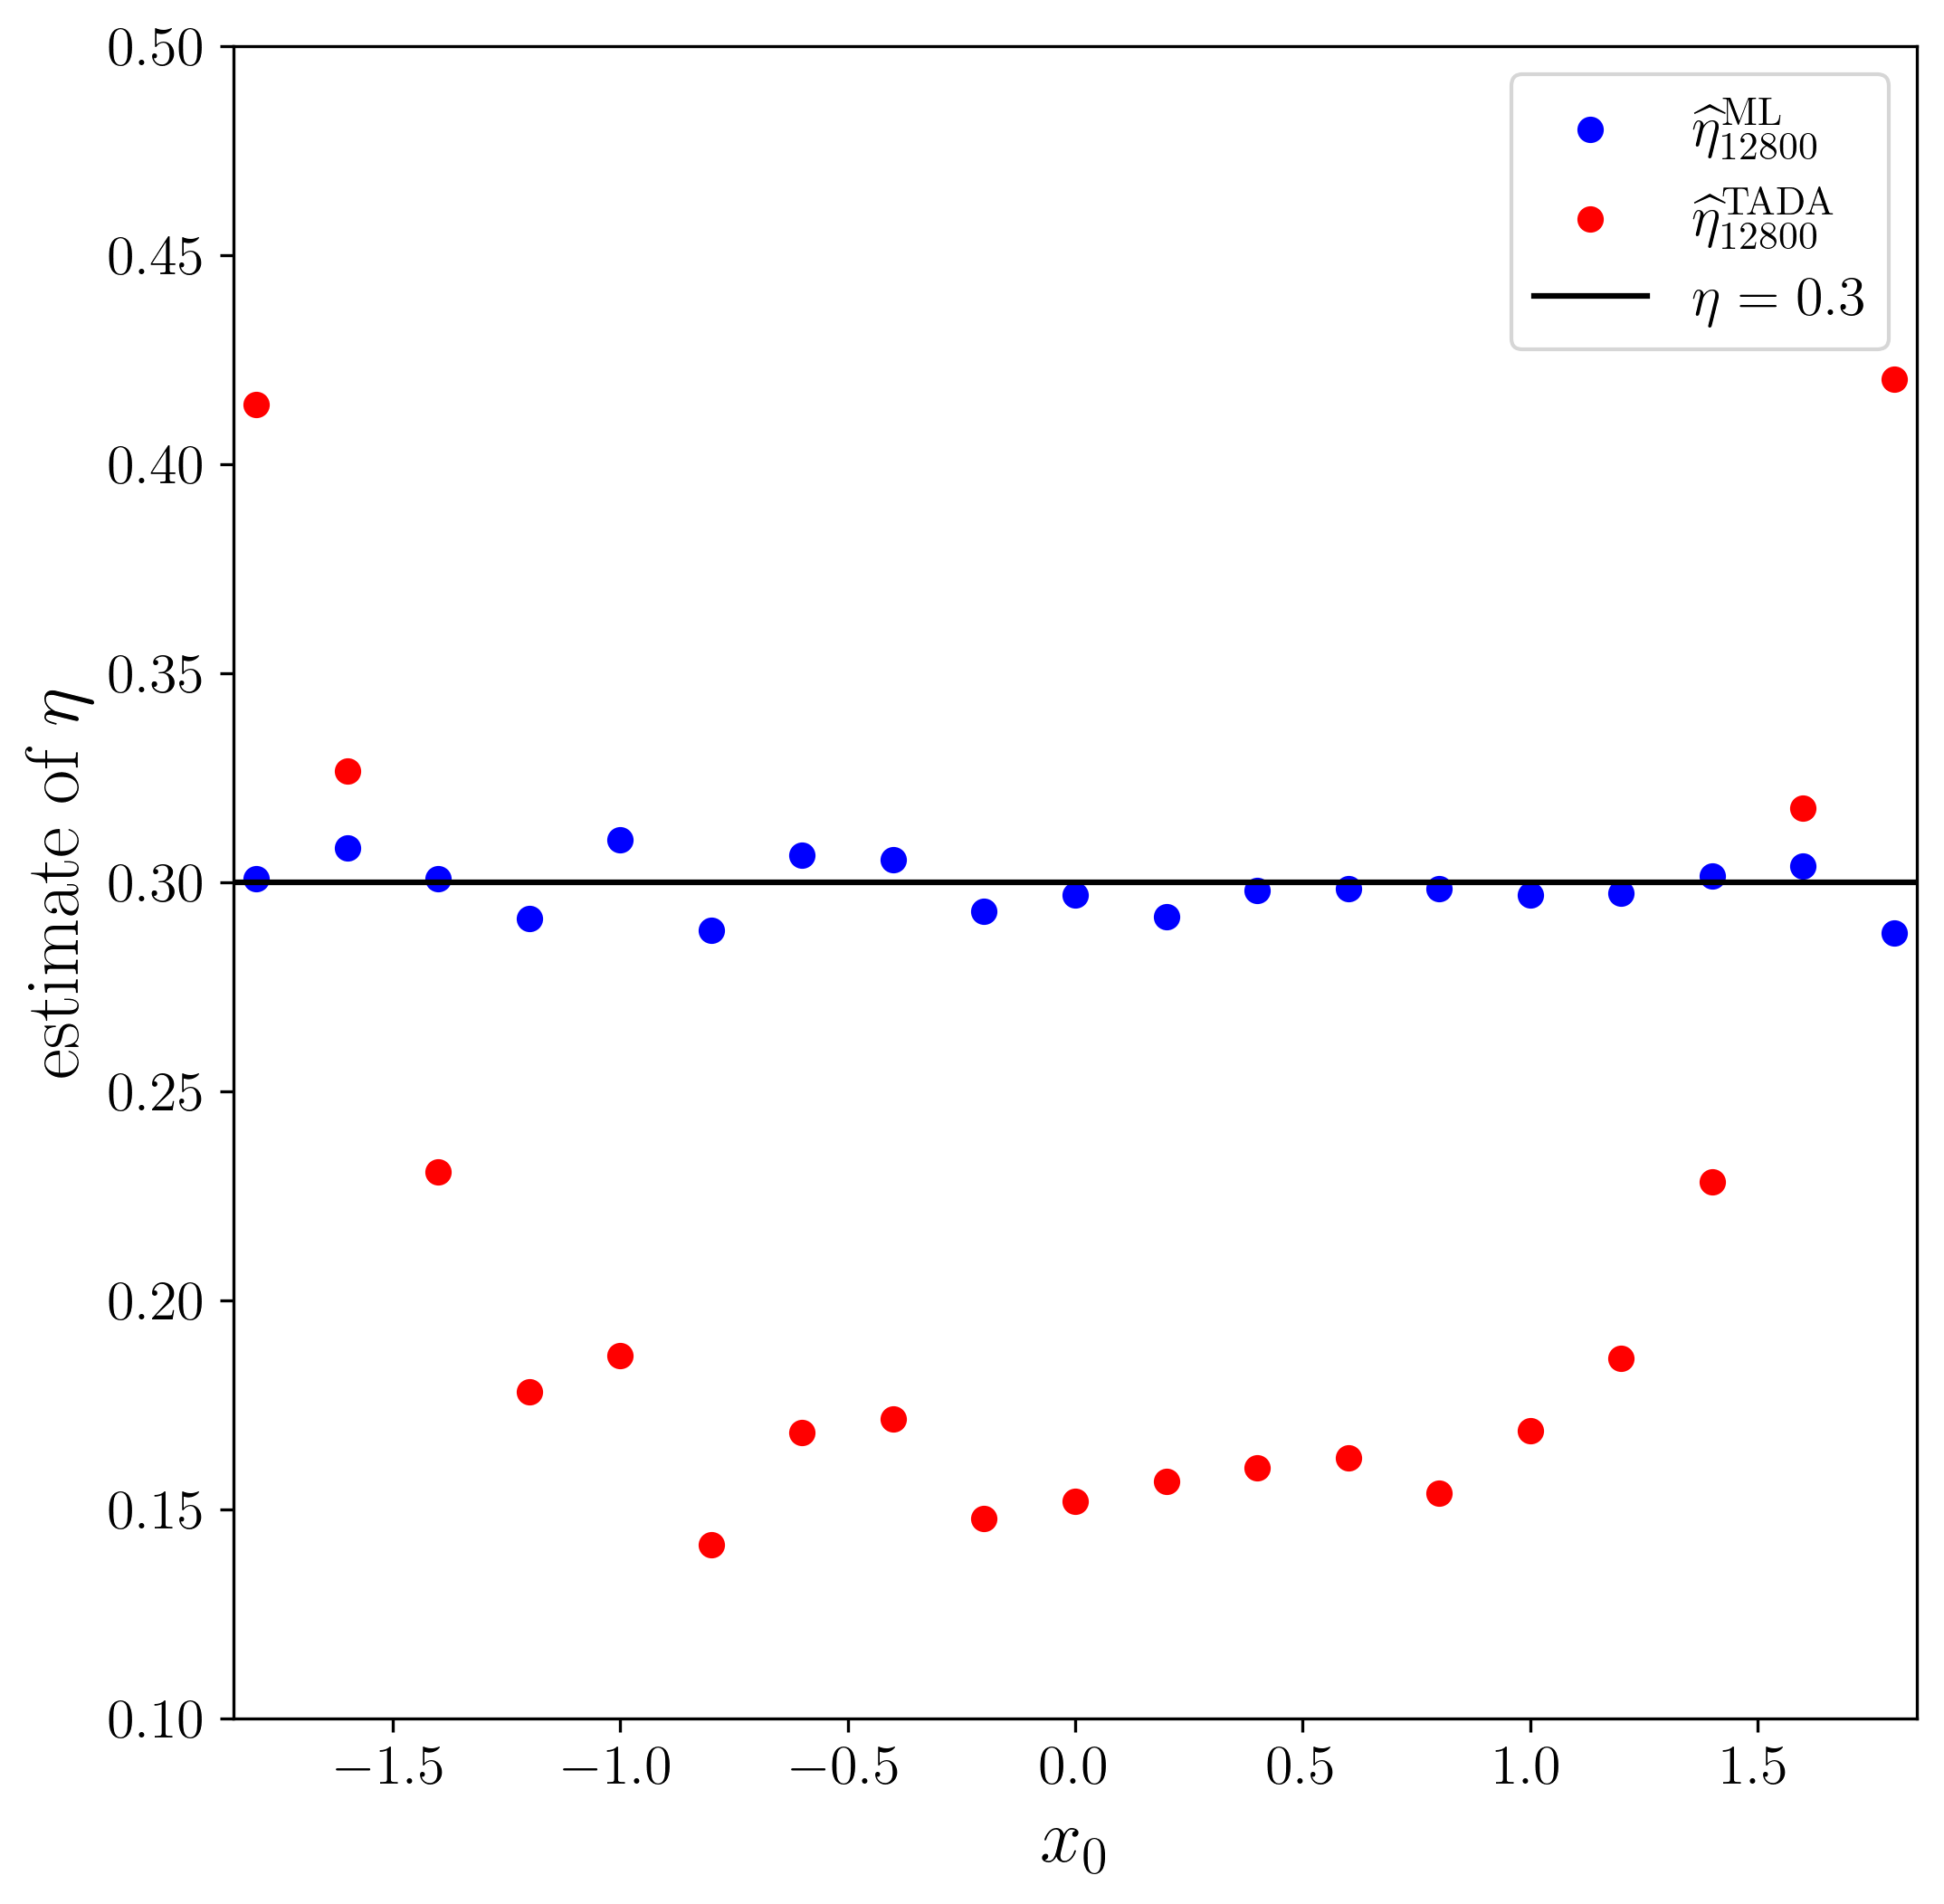

In [12]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_mle_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_tada_arr[num_data_idx, :, 0],
    label=rf"$\widehat{{\eta}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 0], 0, 1, c="k", label=rf"$\eta={paras_true_arr[num_data_idx, 0, 0]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$x_0$", fontsize=20)
ax.set_ylabel(r"estimate of $\eta$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-1.85, 1.85))
ax.set_ylim((0.1, 0.5))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

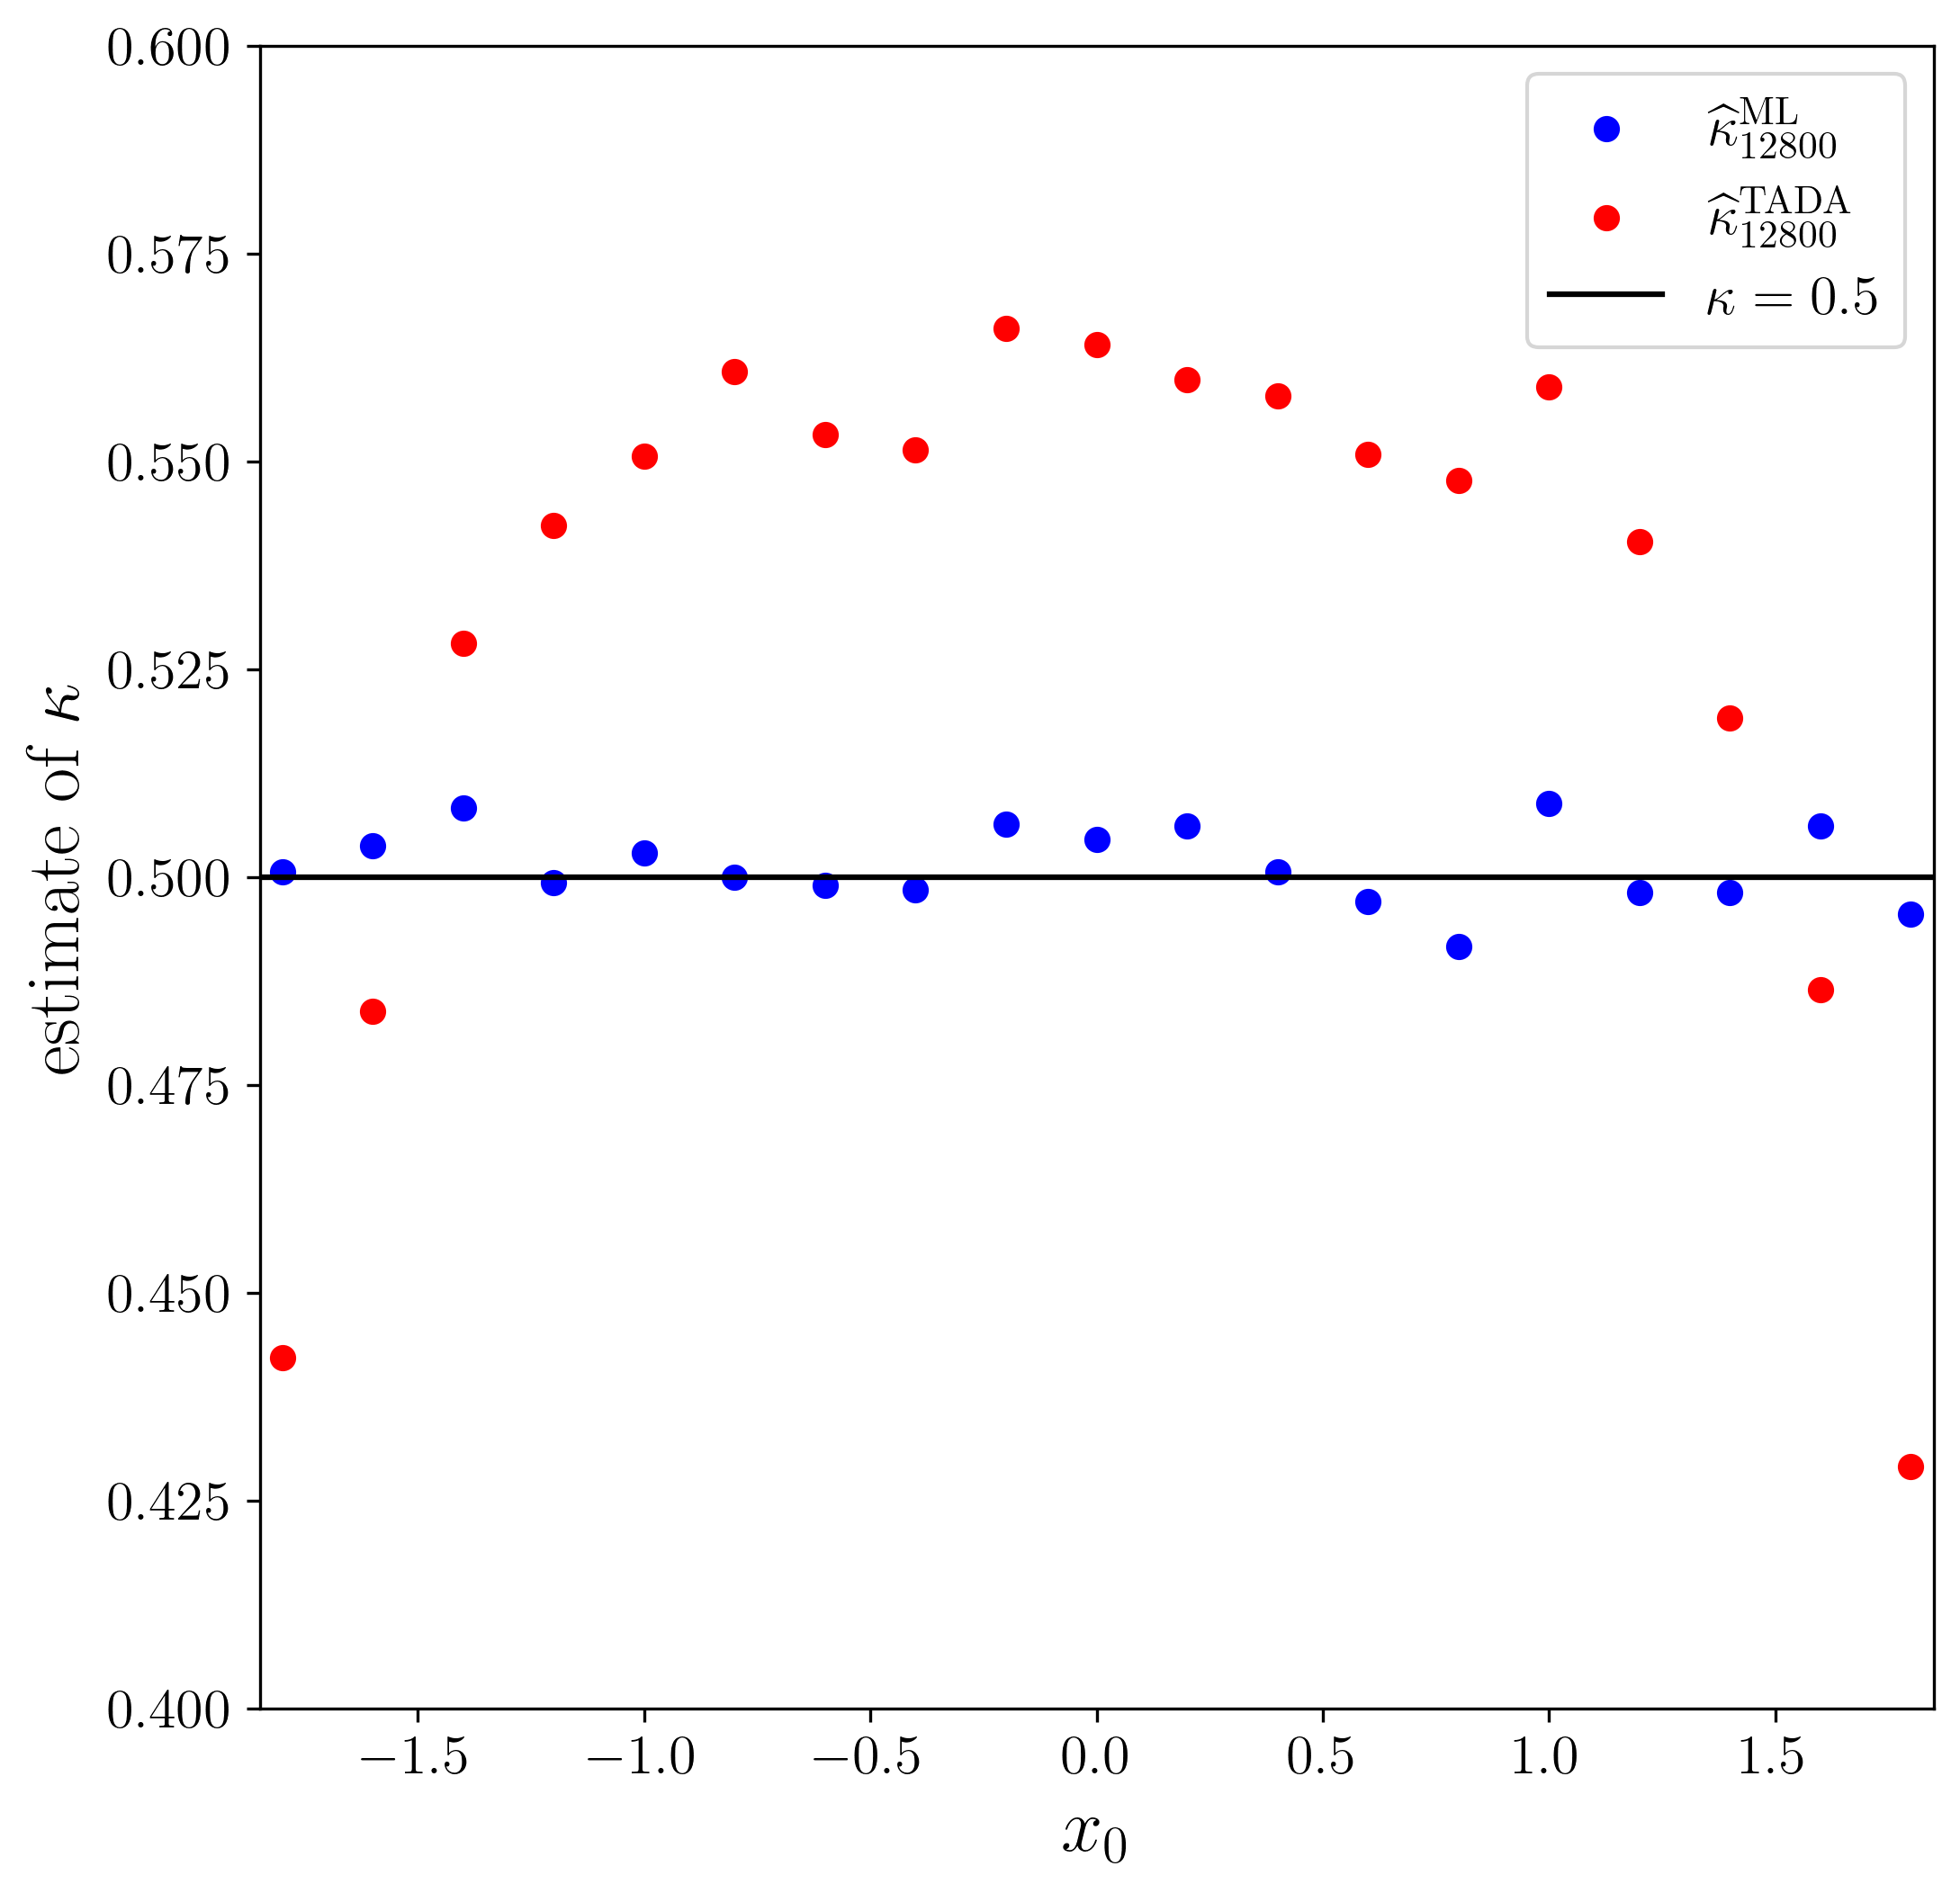

In [14]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_mle_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_tada_arr[num_data_idx, :, 1],
    label=rf"$\widehat{{\kappa}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 1], 0, 1, c="k", label=rf"$\kappa={paras_true_arr[num_data_idx, 0, 1]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$x_0$", fontsize=20)
ax.set_ylabel(r"estimate of $\kappa$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-1.85, 1.85))
ax.set_ylim((0.4, 0.6))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

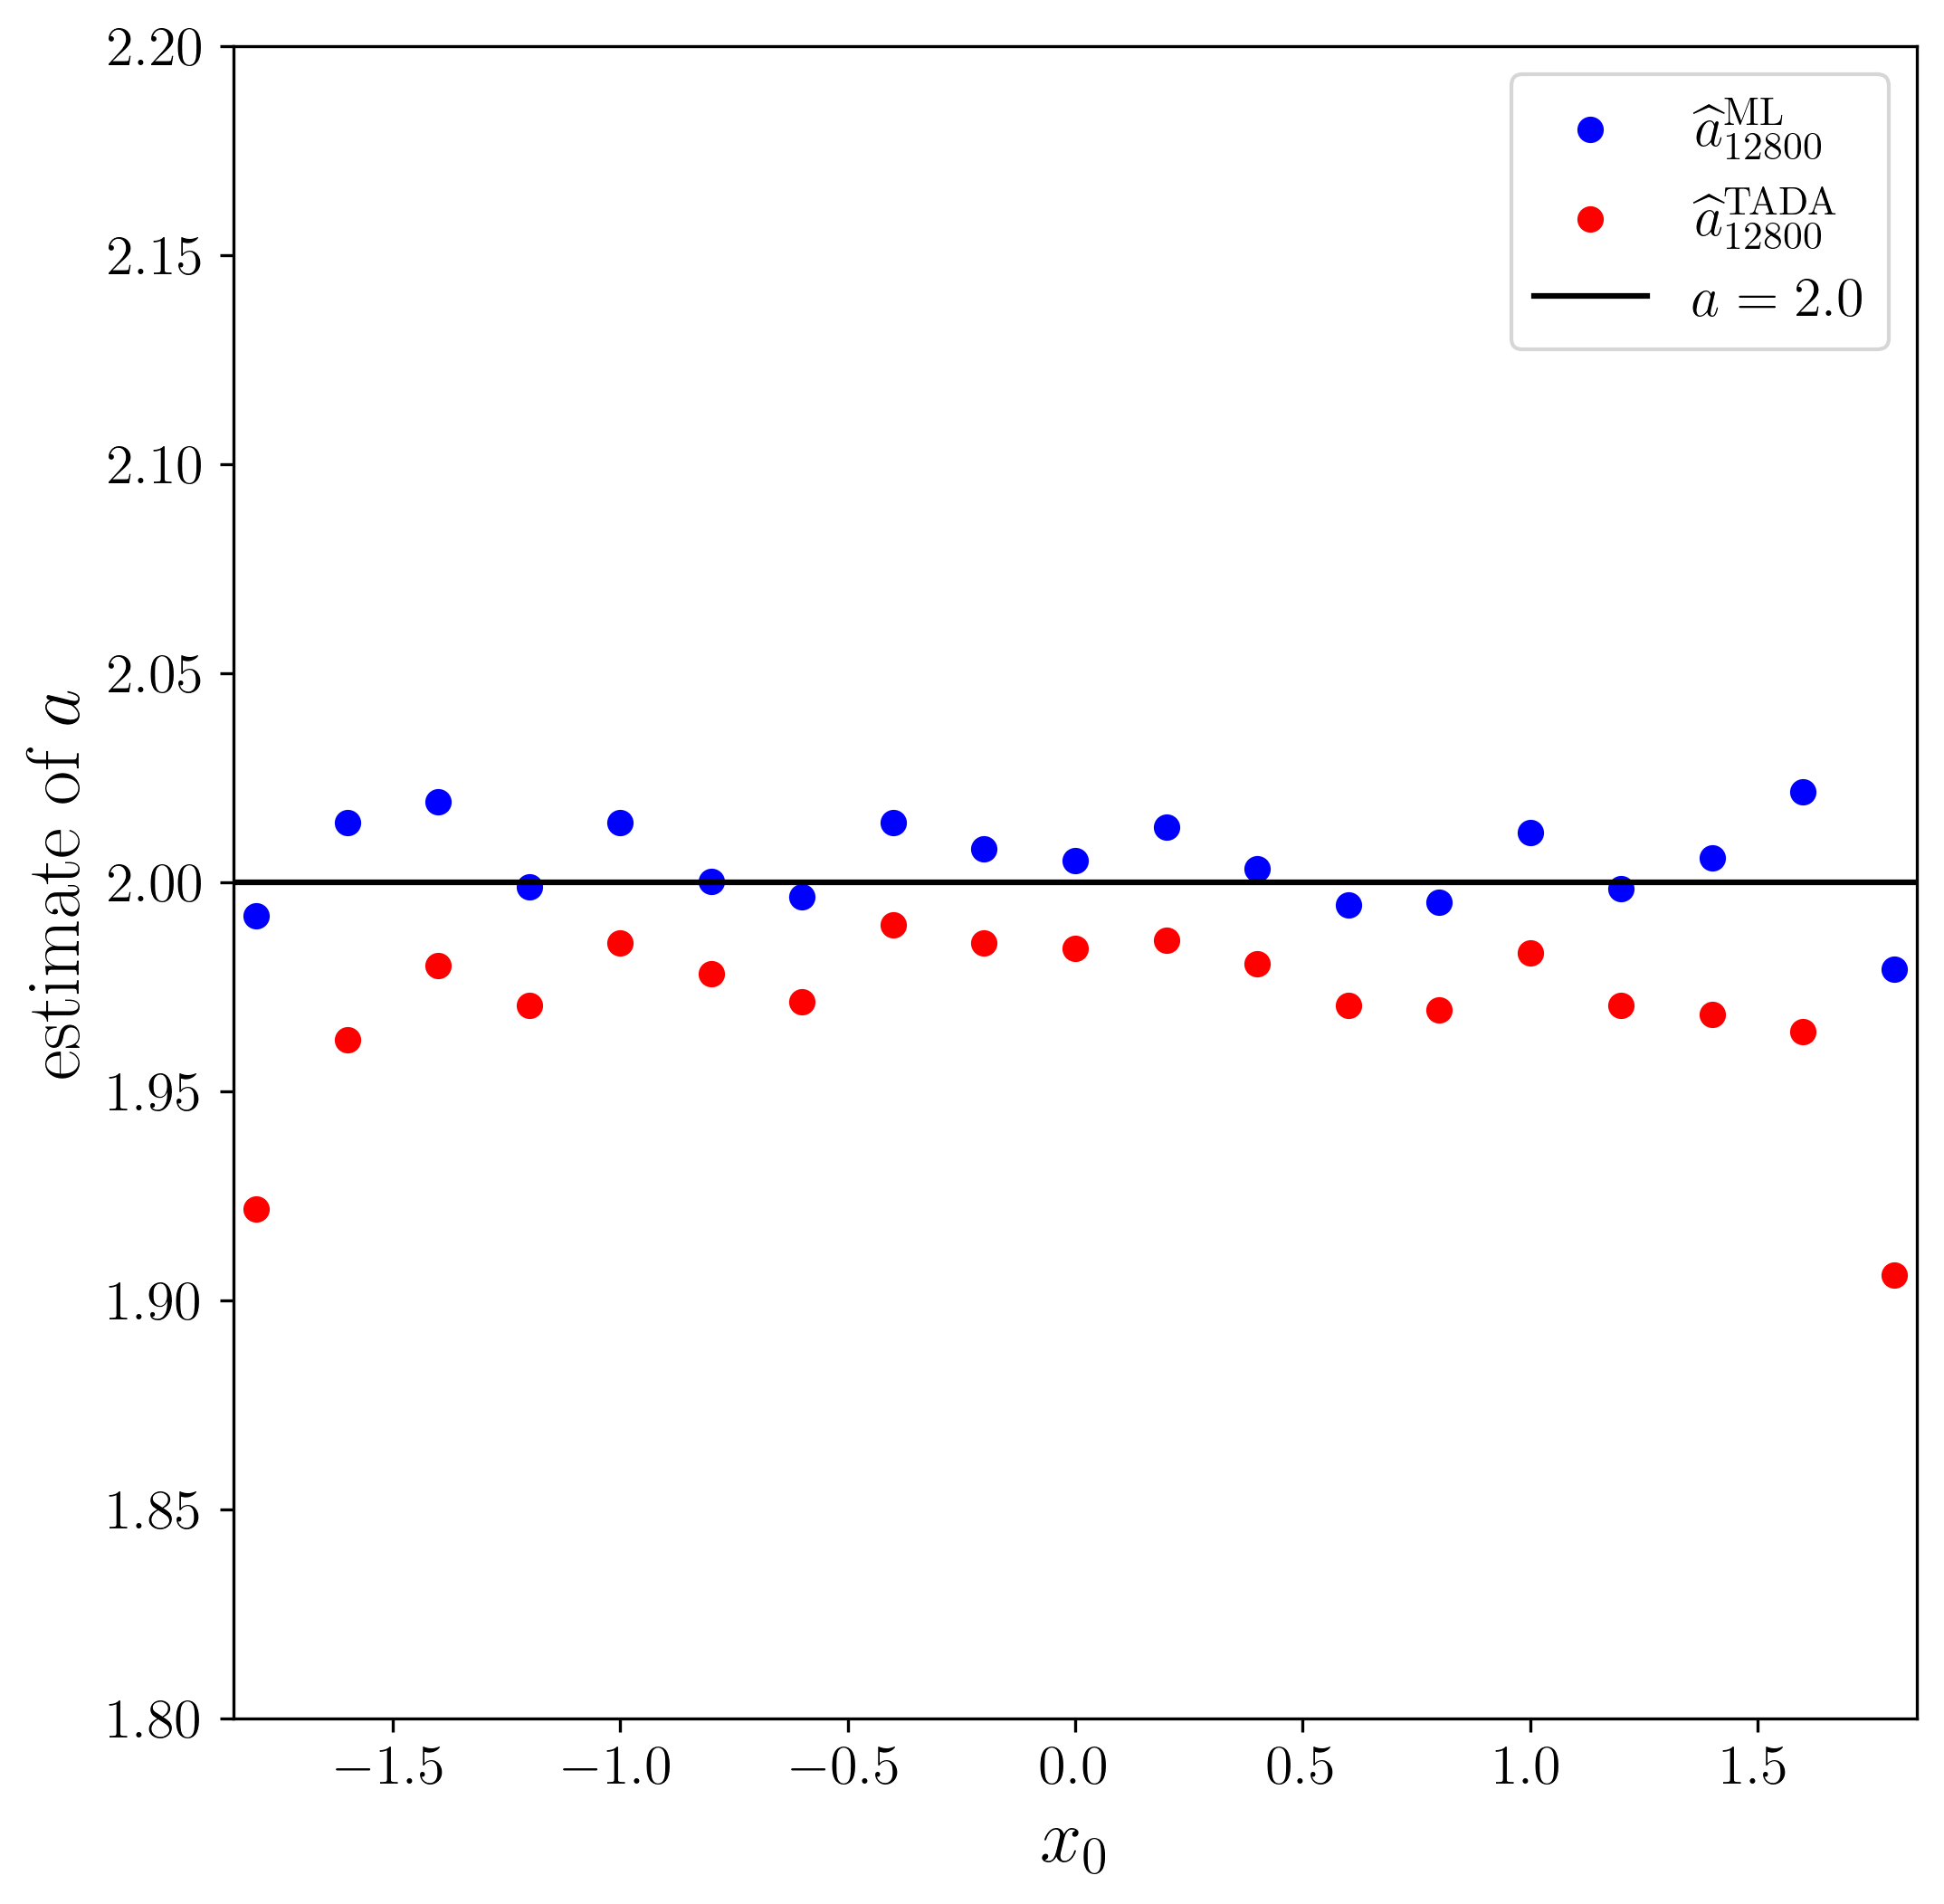

In [18]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_mle_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_tada_arr[num_data_idx, :, 2],
    label=rf"$\widehat{{a}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.axhline(paras_true_arr[num_data_idx, 0, 2], 0, 1, c="k", label=rf"$a={paras_true_arr[num_data_idx, 0, 2]}$")
ax.legend(fontsize=15)
ax.set_xlabel(r"$x_0$", fontsize=20)
ax.set_ylabel(r"estimate of $a$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-1.85, 1.85))
ax.set_ylim((1.8, 2.2))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()

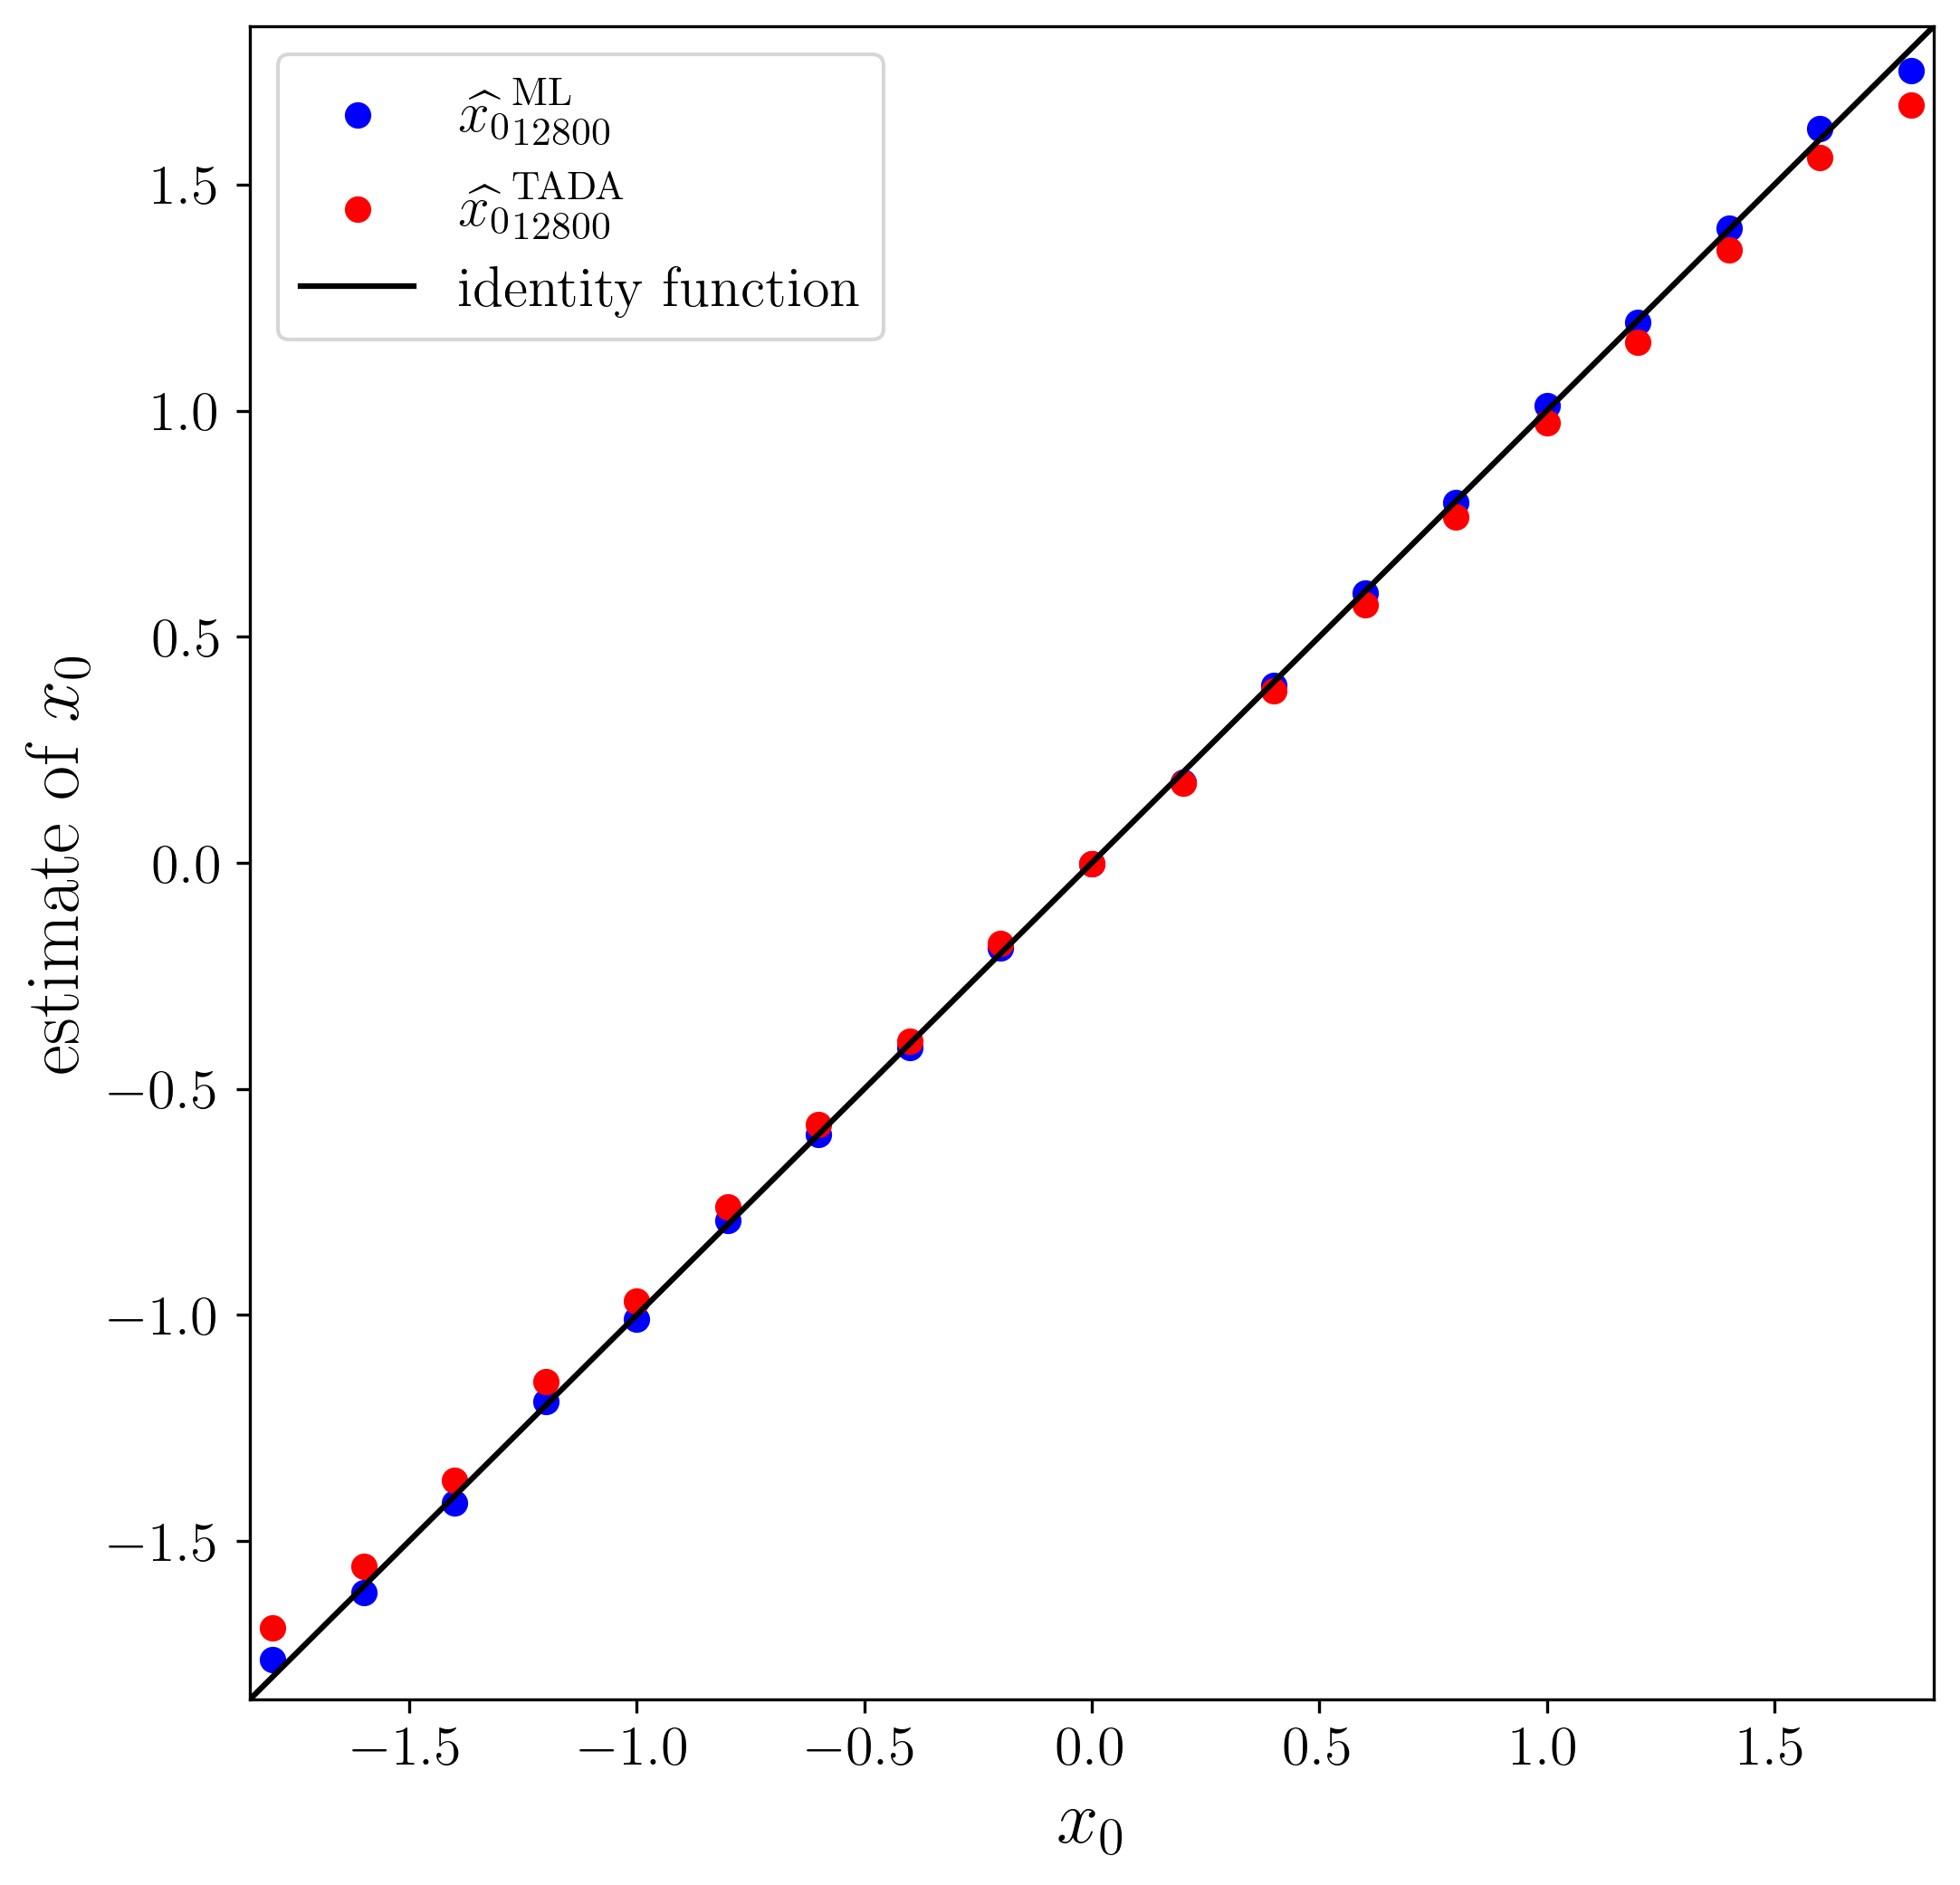

In [24]:
num_data_idx = -2
fig, ax = plt.subplots(1, 1, figsize=(8, 8), dpi=300)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_mle_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{ML}}}}$",
    color="blue",
)
ax.scatter(
    paras_true_arr[num_data_idx, :, 3],
    paras_tada_arr[num_data_idx, :, 3],
    label=rf"$\widehat{{x_0}}_{{{num_data_list[num_data_idx]}}}^{{\text{{TADA}}}}$",
    color="red",
)
ax.plot(
    np.linspace(-1.85, 1.85, 100), np.linspace(-1.85, 1.85, 100), c="k", label="identity function"
)
ax.legend(fontsize=15)
ax.set_xlabel(r"$x_0$", fontsize=20)
ax.set_ylabel(r"estimate of $x_0$", fontsize=20)
ax.tick_params(axis="both", labelsize=15)

ax.set_xlim((-1.85, 1.85))
ax.set_ylim((-1.85, 1.85))

# plt.savefig(f"param_recovery_{num_data_list[num_data_idx]}.png", bbox_inches="tight")


plt.show()